In [32]:
import pandas as pd

df=pd.read_csv("/content/day7_electricity_consumption_practice.csv")
df.head()

,customer_id,city,building_type,season,meter_type,building_area_sqft,occupants,average_temperature_c,humidity_percent,appliance_count,avg_daily_usage_hours,solar_panel,previous_month_kwh,monthly_consumption_kwh
0,CUST01357,Lalitpur,Commercial,Winter,Smart,5443.0,5.0,7.7,49.7,9.0,6.7,No,1449.2,1882.7
1,CUST00985,Bhaktapur,Office,Spring,Smart,4743.0,15.0,16.0,78.8,14.0,13.6,Yes,1794.2,2003.2
2,CUST00860,Kathmandu,Office,Summer,Standard,5140.0,14.0,26.4,59.6,17.0,8.4,No,635.3,2087.7
3,CUST01985,Lalitpur,Office,Spring,Smart,727.0,14.0,31.7,83.0,15.0,8.9,No,911.9,1735.3
4,CUST01294,Chitwan,Residential,Summer,Smart,5577.0,8.0,11.9,30.8,3.0,5.2,No,935.3,1308.8


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2030 entries, 0 to 2029
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              2030 non-null   object 
 1   city                     1990 non-null   object 
 2   building_type            2030 non-null   object 
 3   season                   2030 non-null   object 
 4   meter_type               2030 non-null   object 
 5   building_area_sqft       1988 non-null   float64
 6   occupants                1989 non-null   float64
 7   average_temperature_c    1990 non-null   float64
 8   humidity_percent         2030 non-null   float64
 9   appliance_count          1990 non-null   float64
 10  avg_daily_usage_hours    2030 non-null   float64
 11  solar_panel              2030 non-null   object 
 12  previous_month_kwh       1990 non-null   float64
 13  monthly_consumption_kwh  2030 non-null   float64
dtypes: float64(8), object(6)

In [34]:
df.shape

(2030, 14)

In [35]:
df.duplicated().sum()

np.int64(30)

In [36]:
df.isnull().sum()

,0
customer_id,0
city,40
building_type,0
season,0
meter_type,0
building_area_sqft,42
occupants,41
average_temperature_c,40
humidity_percent,0
appliance_count,40


Remove Duplicate Rows

In [37]:
df=df.drop_duplicates().reset_index(drop=True)

In [38]:
# check the duplicate again
df.duplicated().sum()

np.int64(0)

Handle Missing Values

In [39]:
df['city']=df['city'].fillna(df['city'].mode()[0])

In [40]:
df['city'].isnull().sum()

np.int64(0)

In [41]:
numerical_missing=[
    "building_area_sqft",
    "occupants",
    "average_temperature_c",
    "appliance_count",
    "previous_month_kwh"
]

In [42]:
for col in numerical_missing:
  df[col]=df[col].fillna(df[col].median())

In [43]:
# check the missing values

df.isnull().sum()

,0
customer_id,0
city,0
building_type,0
season,0
meter_type,0
building_area_sqft,0
occupants,0
average_temperature_c,0
humidity_percent,0
appliance_count,0


Statistical Analysis

In [44]:
df.describe()

,building_area_sqft,occupants,average_temperature_c,humidity_percent,appliance_count,avg_daily_usage_hours,previous_month_kwh,monthly_consumption_kwh
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3270.339500,8.17900,20.049550,59.978250,11.303500,9.993600,957.775000,1642.655800
std,1554.114208,4.22207,8.412008,17.446525,5.460155,4.599702,491.942606,326.987989
min,502.000000,1.00000,5.000000,30.000000,2.000000,2.000000,81.100000,649.600000
25%,1909.750000,5.00000,13.000000,44.900000,7.000000,6.000000,549.500000,1422.400000
50%,3311.000000,8.00000,20.100000,59.300000,11.000000,10.000000,953.100000,1641.950000
75%,4608.250000,12.00000,27.100000,75.500000,16.000000,14.000000,1372.825000,1862.100000
max,5999.000000,15.00000,35.000000,90.000000,20.000000,18.000000,1799.800000,2658.300000


Analyze Categorical Features

In [45]:
categorical_feature=[
    "city",
    "building_type",
    "season",
    "meter_type",
    "solar_panel"
]

In [46]:
for col in categorical_feature:
  print("="*50)
  print(f"Column :{col}")
  print("Unique values :",df[col].nunique())
  print(df[col].value_counts())

Column :city
Unique values : 6
city
Kathmandu     385
Biratnagar    335
Chitwan       325
Lalitpur      319
Bhaktapur     319
Pokhara       317
Name: count, dtype: int64
Column :building_type
Unique values : 4
building_type
Residential    888
Office         511
Commercial     421
Industrial     180
Name: count, dtype: int64
Column :season
Unique values : 4
season
Autumn    528
Summer    511
Spring    500
Winter    461
Name: count, dtype: int64
Column :meter_type
Unique values : 2
meter_type
Smart       1318
Standard     682
Name: count, dtype: int64
Column :solar_panel
Unique values : 2
solar_panel
No     1660
Yes     340
Name: count, dtype: int64


Check the Target Distribution

In [47]:
df['monthly_consumption_kwh'].head()

,monthly_consumption_kwh
0,1882.7
1,2003.2
2,2087.7
3,1735.3
4,1308.8


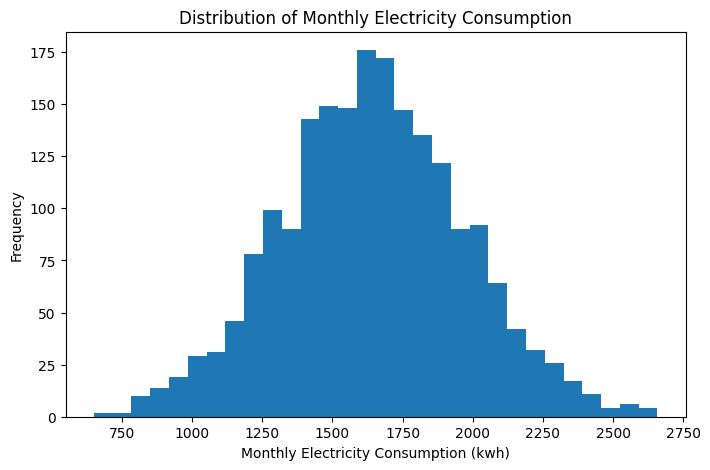

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['monthly_consumption_kwh'],bins=30)
plt.xlabel("Monthly Electricity Consumption (kwh)")
plt.ylabel("Frequency")
plt.title("Distribution of Monthly Electricity Consumption")
plt.show()

In [49]:
df['monthly_consumption_kwh'].describe()

,monthly_consumption_kwh
count,2000.000000
mean,1642.655800
std,326.987989
min,649.600000
25%,1422.400000
50%,1641.950000
75%,1862.100000
max,2658.300000


Correlation Analysis

In [50]:
numerical_feature=[
    "building_area_sqft",
    "occupants",
    "average_temperature_c",
    "humidity_percent",
    "appliance_count",
    "avg_daily_usage_hours",
    "previous_month_kwh",
    "monthly_consumption_kwh"
]

correlation=df[numerical_feature].corr()

print(correlation["monthly_consumption_kwh"].sort_values(ascending=False))

monthly_consumption_kwh    1.000000
avg_daily_usage_hours      0.520702
appliance_count            0.348912
building_area_sqft         0.304467
previous_month_kwh         0.258679
occupants                  0.234687
humidity_percent           0.081117
average_temperature_c      0.065655
Name: monthly_consumption_kwh, dtype: float64


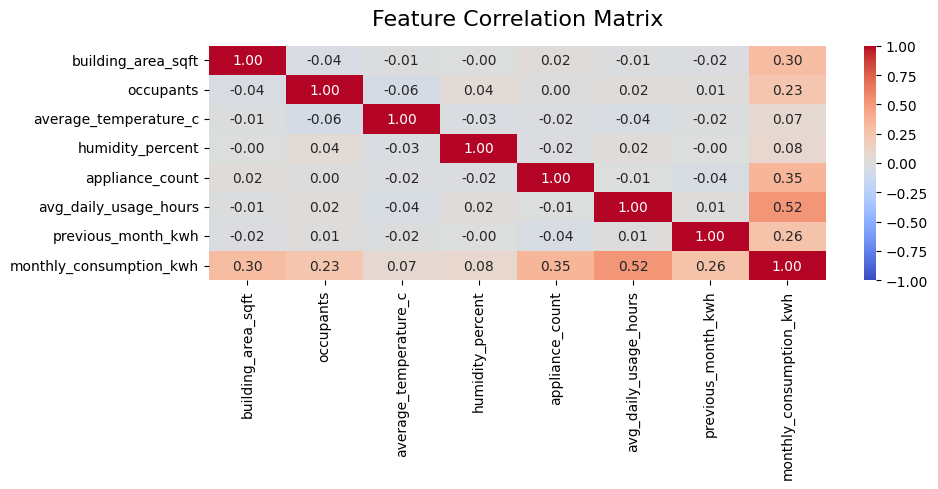

In [51]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Feature Correlation Matrix",fontsize=16,pad=15)
plt.tight_layout()
plt.show()


Check Feature Vs Target Relationships

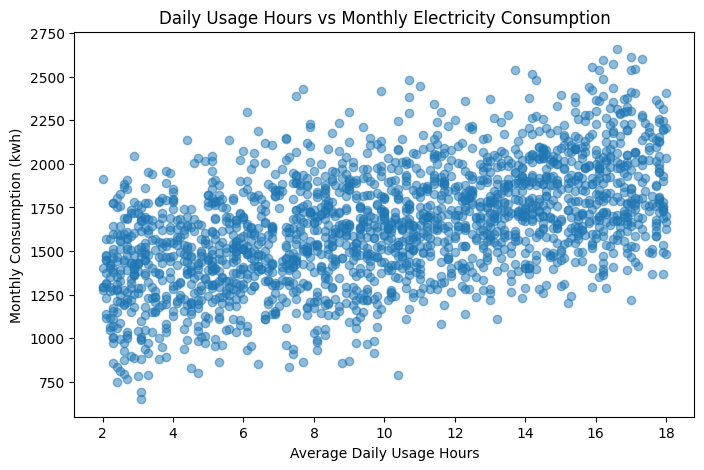

In [52]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['avg_daily_usage_hours'],
    df['monthly_consumption_kwh'],
    alpha=0.5
)

plt.xlabel("Average Daily Usage Hours")
plt.ylabel("Monthly Consumption (kwh)")
plt.title("Daily Usage Hours vs Monthly Electricity Consumption")

plt.show()

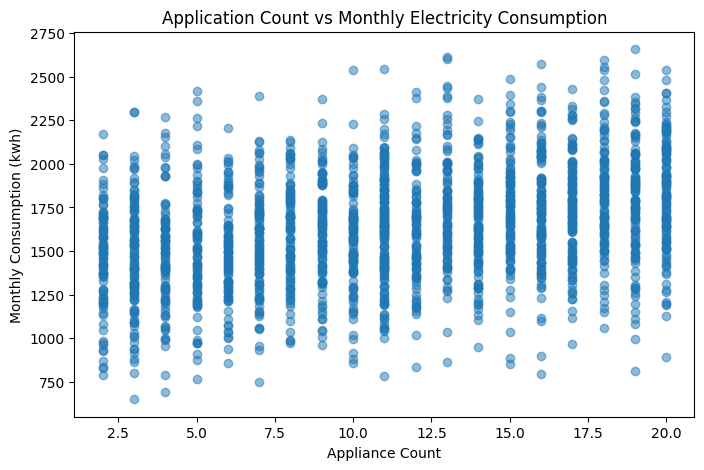

In [53]:
# appliance count
plt.figure(figsize=(8,5))

plt.scatter(
    df['appliance_count'],
    df['monthly_consumption_kwh'],
    alpha=0.5
)

plt.xlabel("Appliance Count")
plt.ylabel("Monthly Consumption (kwh)")
plt.title("Application Count vs Monthly Electricity Consumption")
plt.show()

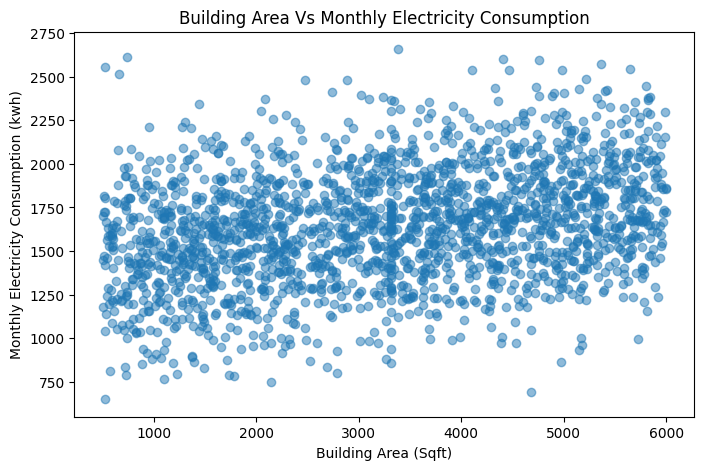

In [54]:
# building Area
plt.figure(figsize=(8,5))

plt.scatter(
    df['building_area_sqft'],
    df['monthly_consumption_kwh'],
    alpha=0.5
)

plt.xlabel("Building Area (Sqft)")
plt.ylabel("Monthly Electricity Consumption (kwh)")
plt.title("Building Area Vs Monthly Electricity Consumption")

plt.show()

We want to know whether different categories have noticeably different average electricity consumption.

In [55]:
# city vs Consumption

df.groupby('city')['monthly_consumption_kwh'].agg(
    ['count',"mean","median"]
).sort_values("mean",ascending=False)

,count,mean,median
city,,,
Chitwan,325,1670.235385,1671.8
Kathmandu,385,1647.051688,1671.3
Pokhara,317,1644.547634,1641.2
Biratnagar,335,1641.987761,1627.2
Lalitpur,319,1635.194357,1649.1
Bhaktapur,319,1615.535110,1607.3


In [56]:
# Building types vs Consumption
df.groupby('building_type')['monthly_consumption_kwh'].agg(
    ['count','mean','median']
).sort_values('mean',ascending=False)

,count,mean,median
building_type,,,
Industrial,180,1987.680556,1973.75
Office,511,1737.503327,1734.20
Commercial,421,1669.284798,1685.60
Residential,888,1505.513514,1512.55


In [57]:
# Season vs Consumption
df.groupby('season')['monthly_consumption_kwh'].agg(
    ['count','mean','median']
).sort_values('mean',ascending=False)

,count,mean,median
season,,,
Summer,511,1704.334442,1699.3
Winter,461,1679.211063,1666.1
Autumn,528,1623.429356,1606.7
Spring,500,1566.219400,1586.0


In [58]:
# Meter types Vs Consumption
df.groupby('meter_type')['monthly_consumption_kwh'].agg(
    ['count','mean','median']
).sort_values('mean',ascending=False)

,count,mean,median
meter_type,,,
Standard,682,1650.807625,1650.90
Smart,1318,1638.437633,1638.75


In [59]:
# solar panel vs Consumption
df.groupby("solar_panel")["monthly_consumption_kwh"].agg(
    ["count", "mean", "median"]
).sort_values("mean", ascending=False)

,count,mean,median
solar_panel,,,
No,1660,1665.861867,1660.75
Yes,340,1529.355588,1527.20


In [60]:
# remove unwanted column
df=df.drop(columns=['customer_id'])

In [61]:
x=df.drop(columns=['monthly_consumption_kwh'])
y=df['monthly_consumption_kwh']

In [62]:
print("x-shape :",x.shape)
print("y-shape :",y.shape)

x-shape : (2000, 12)
y-shape : (2000,)


In [63]:
x.head()

,city,building_type,season,meter_type,building_area_sqft,occupants,average_temperature_c,humidity_percent,appliance_count,avg_daily_usage_hours,solar_panel,previous_month_kwh
0,Lalitpur,Commercial,Winter,Smart,5443.0,5.0,7.7,49.7,9.0,6.7,No,1449.2
1,Bhaktapur,Office,Spring,Smart,4743.0,15.0,16.0,78.8,14.0,13.6,Yes,1794.2
2,Kathmandu,Office,Summer,Standard,5140.0,14.0,26.4,59.6,17.0,8.4,No,635.3
3,Lalitpur,Office,Spring,Smart,727.0,14.0,31.7,83.0,15.0,8.9,No,911.9
4,Chitwan,Residential,Summer,Smart,5577.0,8.0,11.9,30.8,3.0,5.2,No,935.3


In [64]:
y.head()

,monthly_consumption_kwh
0,1882.7
1,2003.2
2,2087.7
3,1735.3
4,1308.8


In [65]:
# verfiy columns
print("Features :")
print(x.columns.tolist())

print("\nTarget")
print(y.name)

Features :
['city', 'building_type', 'season', 'meter_type', 'building_area_sqft', 'occupants', 'average_temperature_c', 'humidity_percent', 'appliance_count', 'avg_daily_usage_hours', 'solar_panel', 'previous_month_kwh']

Target
monthly_consumption_kwh


Train/Test Split

In [66]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("x-train :",x_train.shape)
print("x-test :",x_test.shape)

print("y-train :",y_train.shape)
print("y-test :",y_test.shape)

x-train : (1600, 12)
x-test : (400, 12)
y-train : (1600,)
y-test : (400,)


Identify Feature Types

In [67]:
numerical_feature=x.select_dtypes(
    include=['int64','float64']
).columns.tolist()

categorical_feature=x.select_dtypes(
    include=['object']
).columns.tolist()

print("Numerical Features :")
print(numerical_feature)

print("Categorical Features :")
print(categorical_feature)

Numerical Features :
['building_area_sqft', 'occupants', 'average_temperature_c', 'humidity_percent', 'appliance_count', 'avg_daily_usage_hours', 'previous_month_kwh']
Categorical Features :
['city', 'building_type', 'season', 'meter_type', 'solar_panel']


One-Hot Encoding

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor=ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown='ignore'),
            categorical_feature
        )
    ],
    remainder='passthrough'
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


Build Baseline Decision Tree

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

dt_model =Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",DecisionTreeRegressor(
            random_state=42
        ))
    ]
)

In [70]:
dt_model.fit(x_train,y_train)
print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


Make predictions

In [71]:
y_pred=dt_model.predict(x_test)

print("Predictions generated successfully")
print(y_pred[:10])

Predictions generated successfully
[1975.4 1477.4 2136.8 1509.2 1526.1 2093.6 1311.6 2151.3 1308.8 1542.6]


Evaluate the Baseline Model

In [72]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("MAE :",mae)
print("MSE :",mse)
print("RMSE :",rmse)
print("R2 :",r2)

MAE : 184.85375
MSE : 52066.58977500001
RMSE : 228.18104604677401
R2 : 0.5875212900195879


Check Overfitting

In [73]:
y_train_pred = dt_model.predict(x_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("Training Performance")
print("MAE :", train_mae)
print("MSE :", train_mse)
print("RMSE:", train_rmse)
print("R²  :", train_r2)

print("\nTesting Performance")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Training Performance
MAE : 0.0
MSE : 0.0
RMSE: 0.0
R²  : 1.0

Testing Performance
MAE : 184.85375
MSE : 52066.58977500001
RMSE: 228.18104604677401
R²  : 0.5875212900195879


Control tree complexity

In [74]:
depths=[2,3,4,5,6,8,10,12,15,20]

results=[]
for depth in depths:
  model = Pipeline(
      steps=[
          ('preprocessor',preprocessor),
          ('model',DecisionTreeRegressor(
              max_depth=depth,
              random_state=42
          ))
      ]
  )

  model.fit(x_train,y_train)

  train_pred=model.predict(x_train)
  test_pred=model.predict(x_test)

  train_r2=r2_score(y_train,train_pred)
  test_r2=r2_score(y_test, test_pred)

  test_mae=mean_absolute_error(y_test,test_pred)
  test_rmse=np.sqrt(
      mean_squared_error(y_test,test_pred)
  )

  results.append([
      depth,
      train_r2,
      test_r2,
      test_mae,
      test_rmse
  ])

  depth_results = pd.DataFrame(
      results,
      columns=[
          "max_depth",
          "Train_R2",
          "Test_R2",
          "Test_MAE",
          "Test_RMSE"
      ]
  )

  print(depth_results)

   max_depth  Train_R2   Test_R2    Test_MAE   Test_RMSE
0          2  0.352277  0.308649  236.075815  295.412016
   max_depth  Train_R2   Test_R2    Test_MAE   Test_RMSE
0          2  0.352277  0.308649  236.075815  295.412016
1          3  0.464131  0.424057  214.710029  269.630108
   max_depth  Train_R2   Test_R2    Test_MAE   Test_RMSE
0          2  0.352277  0.308649  236.075815  295.412016
1          3  0.464131  0.424057  214.710029  269.630108
2          4  0.562298  0.510883  201.019561  248.476315
   max_depth  Train_R2   Test_R2    Test_MAE   Test_RMSE
0          2  0.352277  0.308649  236.075815  295.412016
1          3  0.464131  0.424057  214.710029  269.630108
2          4  0.562298  0.510883  201.019561  248.476315
3          5  0.657513  0.561700  190.738045  235.214793
   max_depth  Train_R2   Test_R2    Test_MAE   Test_RMSE
0          2  0.352277  0.308649  236.075815  295.412016
1          3  0.464131  0.424057  214.710029  269.630108
2          4  0.562298  0.51088

Visualize the effect

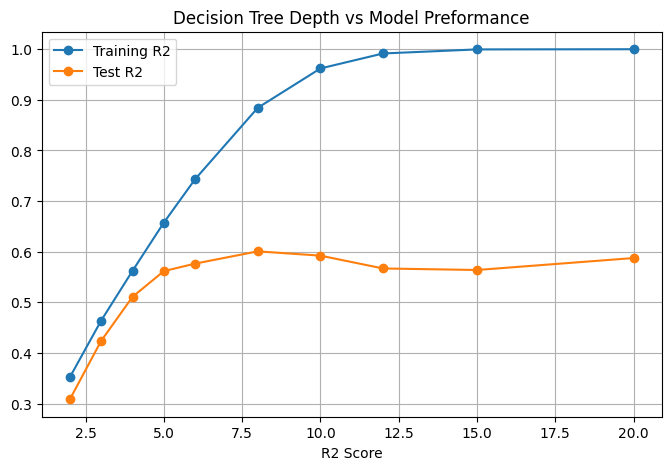

In [76]:
plt.figure(figsize=(8,5))

plt.plot(
    depth_results["max_depth"],
    depth_results["Train_R2"],
    marker="o",
    label="Training R2"
)

plt.plot(
    depth_results["max_depth"],
    depth_results["Test_R2"],
    marker="o",
    label="Test R2"
)

plt.xlabel("Maximum Tree Depth")
plt.xlabel("R2 Score")
plt.title("Decision Tree Depth vs Model Preformance")
plt.legend()
plt.grid(True)
plt.show()

Test min simples split

In [77]:
split_values = [2, 5, 10, 20, 30, 50]

results_split = []

for split in split_values:

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", DecisionTreeRegressor(
                max_depth=8,
                min_samples_split=split,
                random_state=42
            ))
        ]
    )

    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    test_mae = mean_absolute_error(y_test, test_pred)

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    results_split.append([
        split,
        train_r2,
        test_r2,
        test_mae,
        test_rmse
    ])

split_results = pd.DataFrame(
    results_split,
    columns=[
        "min_samples_split",
        "Train_R2",
        "Test_R2",
        "Test_MAE",
        "Test_RMSE"
    ]
)

print(split_results)

   min_samples_split  Train_R2   Test_R2    Test_MAE   Test_RMSE
0                  2  0.884313  0.600725  181.448789  224.499294
1                  5  0.881355  0.596179  183.172220  225.773704
2                 10  0.864110  0.600333  181.595206  224.609362
3                 20  0.822599  0.617010  179.305421  219.873394
4                 30  0.786473  0.610785  178.445123  221.653013
5                 50  0.730538  0.598321  180.267150  225.173938


Tune min_samples_leaf

In [78]:
leaf_values = [1, 2, 5, 10, 15, 20, 30]

results_leaf = []

for leaf in leaf_values:

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", DecisionTreeRegressor(
                max_depth=8,
                min_samples_split=20,
                min_samples_leaf=leaf,
                random_state=42
            ))
        ]
    )

    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    test_mae = mean_absolute_error(y_test, test_pred)

    test_rmse = np.sqrt(
        mean_squared_error(y_test, test_pred)
    )

    results_leaf.append([
        leaf,
        train_r2,
        test_r2,
        test_mae,
        test_rmse
    ])

leaf_results = pd.DataFrame(
    results_leaf,
    columns=[
        "min_samples_leaf",
        "Train_R2",
        "Test_R2",
        "Test_MAE",
        "Test_RMSE"
    ]
)

print(leaf_results)

   min_samples_leaf  Train_R2   Test_R2    Test_MAE   Test_RMSE
0                 1  0.822599  0.617010  179.305421  219.873394
1                 2  0.822120  0.628564  176.275837  216.531485
2                 5  0.818443  0.632734  175.714663  215.312423
3                10  0.804778  0.626004  176.715782  217.276366
4                15  0.755447  0.602024  179.641944  224.133753
5                20  0.719942  0.595765  179.249278  225.889328
6                30  0.673551  0.596254  177.307169  225.752625


Train final model

In [80]:
final_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=8,
            min_samples_split=20,
            min_samples_leaf=5,
            random_state=42
        ))
    ]
)

final_model.fit(x_train, y_train)

print("Final Decision Tree Regression Model trained successfully.")

Final Decision Tree Regression Model trained successfully.


Evaluate

In [81]:
train_pred = final_model.predict(x_train)
test_pred = final_model.predict(x_test)

print("Final Model Performance")
print("=" * 40)

print("Training Performance")
print("MAE :", mean_absolute_error(y_train, train_pred))
print("MSE :", mean_squared_error(y_train, train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))
print("R²  :", r2_score(y_train, train_pred))

print("\nTesting Performance")
print("MAE :", mean_absolute_error(y_test, test_pred))
print("MSE :", mean_squared_error(y_test, test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, test_pred)))
print("R²  :", r2_score(y_test, test_pred))

Final Model Performance
Training Performance
MAE : 106.76255058140212
MSE : 18510.50025519058
RMSE: 136.053299317549
R²  : 0.8184429666604336

Testing Performance
MAE : 175.71466326250317
MSE : 46359.439407316146
RMSE: 215.3124227891093
R²  : 0.6327341228841823


Actual vs Predicted

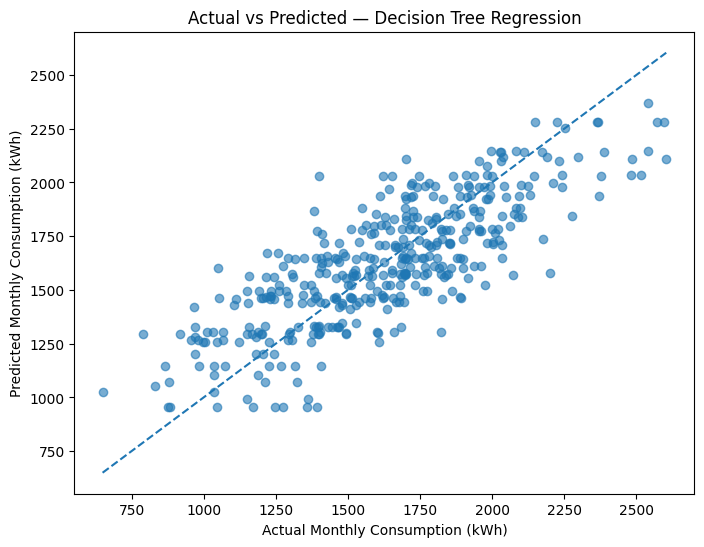

In [82]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    test_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Monthly Consumption (kWh)")
plt.ylabel("Predicted Monthly Consumption (kWh)")
plt.title("Actual vs Predicted — Decision Tree Regression")

plt.show()

Residual Analysis

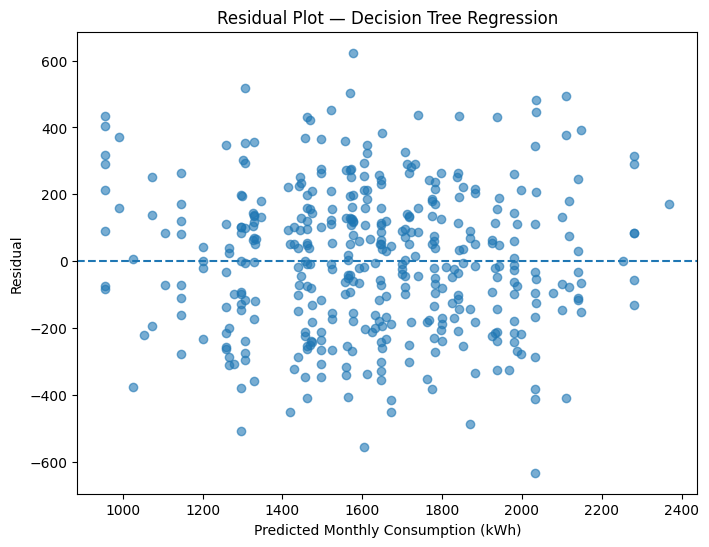

In [83]:
residuals = y_test - test_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Monthly Consumption (kWh)")
plt.ylabel("Residual")
plt.title("Residual Plot — Decision Tree Regression")

plt.show()

Feature Importance

In [84]:
# Get trained Decision Tree model
tree_model = final_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importance = tree_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

                             Feature  Importance
23  remainder__avg_daily_usage_hours    0.344307
9     cat__building_type_Residential    0.179643
22        remainder__appliance_count    0.154528
18     remainder__building_area_sqft    0.122990
24     remainder__previous_month_kwh    0.076609
7      cat__building_type_Industrial    0.051600
19              remainder__occupants    0.025858
20  remainder__average_temperature_c    0.015397
21       remainder__humidity_percent    0.011317
11                cat__season_Spring    0.004882
16               cat__solar_panel_No    0.004438
12                cat__season_Summer    0.004332
17              cat__solar_panel_Yes    0.002142
6      cat__building_type_Commercial    0.001958
2                  cat__city_Chitwan    0.000000
0                cat__city_Bhaktapur    0.000000
1               cat__city_Biratnagar    0.000000
8          cat__building_type_Office    0.000000
5                  cat__city_Pokhara    0.000000
3                cat

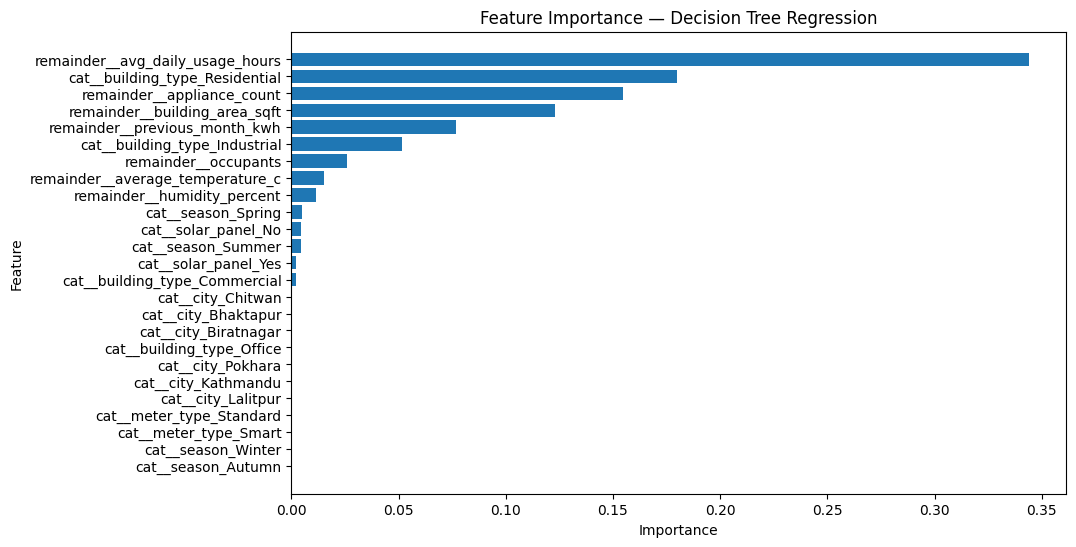

In [85]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance — Decision Tree Regression")

plt.gca().invert_yaxis()

plt.show()

Again Actual vs Predicted

In [86]:
# Predictions on test data
y_pred = final_model.predict(x_test)

# Create comparison DataFrame
prediction_df = pd.DataFrame({
    "Actual Consumption": y_test.values,
    "Predicted Consumption": y_pred,
    "Error": y_test.values - y_pred
})

# Show first 10 predictions
prediction_df.head(10)

,Actual Consumption,Predicted Consumption,Error
0,1999.7,1782.522500,217.177500
1,1890.3,1648.160870,242.139130
2,2387.4,2140.713333,246.686667
3,1231.2,1471.255556,-240.055556
4,1734.2,1648.160870,86.039130
5,1721.9,1998.769231,-276.869231
6,1620.8,1460.742857,160.057143
7,2210.8,1998.769231,212.030769
8,1608.0,1259.623529,348.376471
9,1458.3,1467.927273,-9.627273


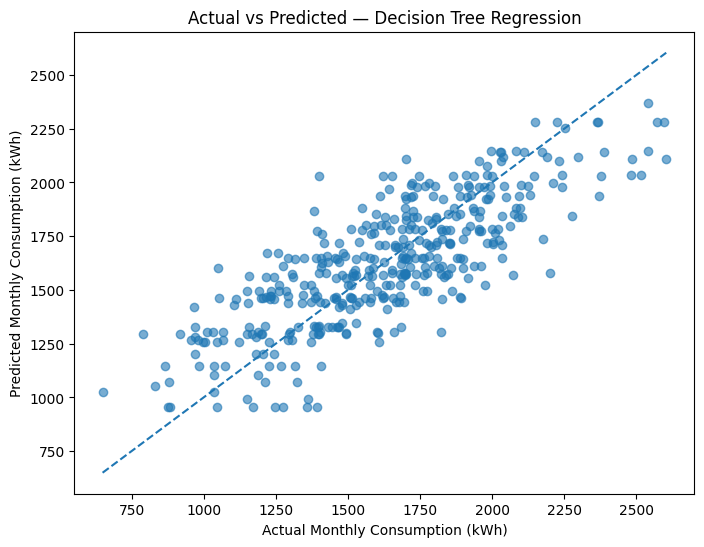

In [87]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Monthly Consumption (kWh)")
plt.ylabel("Predicted Monthly Consumption (kWh)")
plt.title("Actual vs Predicted — Decision Tree Regression")

plt.show()

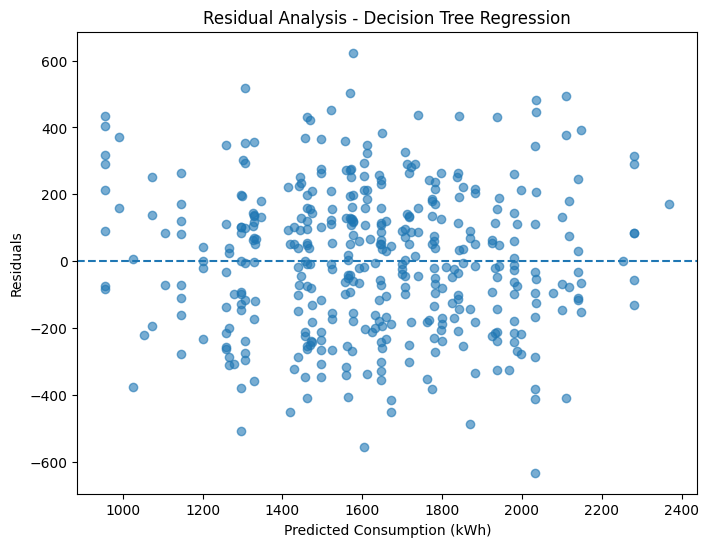

In [88]:
residuals = y_test.values - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Consumption (kWh)")
plt.ylabel("Residuals")
plt.title("Residual Analysis - Decision Tree Regression")

plt.show()

Save the model

In [89]:
import joblib

# Save complete final pipeline
joblib.dump(final_model, "day7_decision_tree_regression.pkl")

print("Model saved successfully!")

Model saved successfully!
